##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import glob
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

In [2]:
seed = 23

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [6]:
DATASET_PATH = r"C:\Users\fh236\Downloads\action_youtube_naudio"

IMAGE_HEIGHT = 64
IMAGE_WIDTH = 64

# I selected 3 classes from the dataset
classes = ["trampoline_jumping", "horse_riding", "tennis_swing"]

print("Dataset path:", DATASET_PATH)
print("Classes used:")
print(classes)

Dataset path: C:\Users\fh236\Downloads\action_youtube_naudio
Classes used:
['trampoline_jumping', 'horse_riding', 'tennis_swing']


In [7]:
video_extensions = ["*.avi", "*.mpg", "*.mp4", "*.mov"]

videos_list = []

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)

    class_videos = []

    for ext in video_extensions:
        videos = glob.glob(os.path.join(class_folder, "**", ext), recursive=True)
        class_videos.extend(videos)

    videos_list.append(class_videos)

    print(class_name, "videos:", len(class_videos))

print("Done loading videos.")

trampoline_jumping videos: 119
horse_riding videos: 198
tennis_swing videos: 167
Done loading videos.


In [8]:
for i in range(len(classes)):
    if len(videos_list[i]) == 0:
        print("No videos found for:", classes[i])
    else:
        print(classes[i], "example video:", videos_list[i][0])

trampoline_jumping example video: C:\Users\fh236\Downloads\action_youtube_naudio\trampoline_jumping\v_jumping_01\v_jumping_01_01.avi
horse_riding example video: C:\Users\fh236\Downloads\action_youtube_naudio\horse_riding\v_riding_01\v_riding_01_01.avi
tennis_swing example video: C:\Users\fh236\Downloads\action_youtube_naudio\tennis_swing\v_tennis_01\v_tennis_01_01.avi


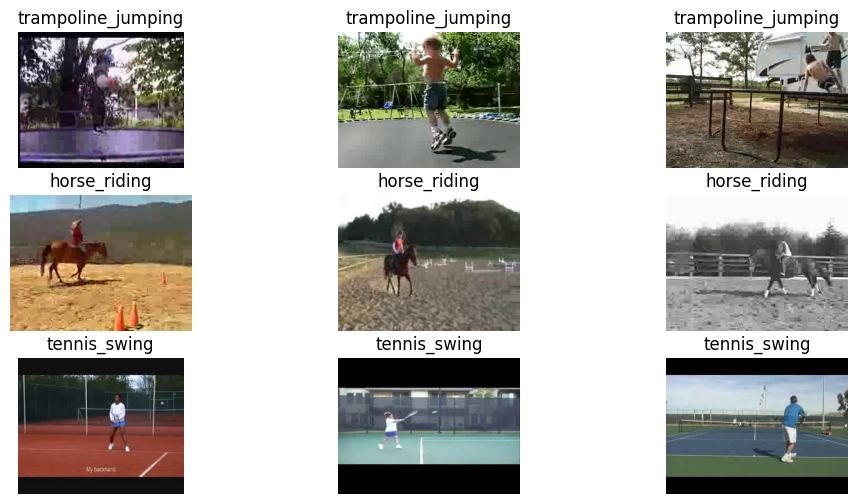

In [9]:
plt.figure(figsize=(12, 6))

image_number = 1

for class_index in range(len(classes)):
    sample_videos = random.sample(videos_list[class_index], 3)

    for video_path in sample_videos:
        video = cv2.VideoCapture(video_path)
        success, frame = video.read()
        video.release()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            plt.subplot(3, 3, image_number)
            plt.imshow(frame)
            plt.title(classes[class_index])
            plt.axis("off")

            image_number += 1

plt.show()

In [10]:
def extract_frames(video_path):
    frames = []

    video = cv2.VideoCapture(video_path)
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    # I will take 20 frames from each video
    number_of_frames = 20

    if total_frames == 0:
        video.release()
        return frames

    skip = max(total_frames // number_of_frames, 1)

    for i in range(number_of_frames):
        video.set(cv2.CAP_PROP_POS_FRAMES, i * skip)

        success, frame = video.read()

        if success:
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))
            frame = frame / 255.0
            frames.append(frame)

    video.release()

    return frames

In [11]:
features = []
labels = []

max_frames_per_class = 2000

for class_index in range(len(classes)):
    print("Working on class:", classes[class_index])

    class_frames = []

    for video_path in videos_list[class_index]:
        frames = extract_frames(video_path)
        class_frames.extend(frames)

    # To make classes more balanced
    if len(class_frames) > max_frames_per_class:
        class_frames = random.sample(class_frames, max_frames_per_class)

    for frame in class_frames:
        features.append(frame)
        labels.append(class_index)

    print("Frames used:", len(class_frames))

features = np.array(features)
labels = np.array(labels)

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

Working on class: trampoline_jumping
Frames used: 2000
Working on class: horse_riding
Frames used: 2000
Working on class: tennis_swing
Frames used: 2000
Features shape: (6000, 64, 64, 3)
Labels shape: (6000,)


In [13]:
labels_one_hot = to_categorical(labels, num_classes=len(classes))

print("Labels shape:", labels.shape)
print("One hot labels shape:", labels_one_hot.shape)

Labels shape: (6000,)
One hot labels shape: (6000, 3)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels_one_hot,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
    stratify=labels
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4800, 64, 64, 3)
Testing data: (1200, 64, 64, 3)


In [15]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation="relu", padding="same",
                 input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.4))

model.add(Dense(len(classes), activation="softmax"))

model.summary()

c:\Users\fh236\.conda\envs\cv_lab\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 39s 290ms/step - accuracy: 0.9661 - loss: 0.1183 - val_accuracy: 0.3344 - val_loss: 6.0750
Epoch 2/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 225ms/step - accuracy: 0.9880 - loss: 0.0441 - val_accuracy: 0.3438 - val_loss: 4.0917
Epoch 3/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step - accuracy: 0.9867 - loss: 0.0430 - val_accuracy: 0.5688 - val_loss: 2.2910
Epoch 4/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step - accuracy: 0.9919 - loss: 0.0286 - val_accuracy: 0.9708 - val_loss: 0.0928
Epoch 5/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 224ms/step - accuracy: 0.9924 - loss: 0.0264 - val_accuracy: 0.9208 - val_loss: 0.2048
Epoch 6/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 27s 225ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.7885 - val_loss: 0.8668


In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test loss:", loss)
print("Test accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9683 - loss: 0.0892
Test loss: 0.08919119089841843
Test accuracy: 0.9683333039283752


In [21]:
student_name = "Fai_Alotaibi"

save_path = f"{student_name}_ucf11_model.h5"

model.save(save_path)

print(f"Model saved as {save_path}")

Model saved as Fai_Alotaibi_ucf11_model.h5


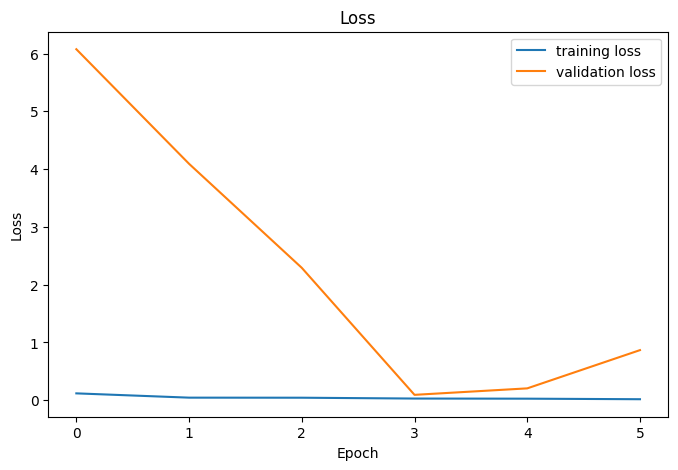

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

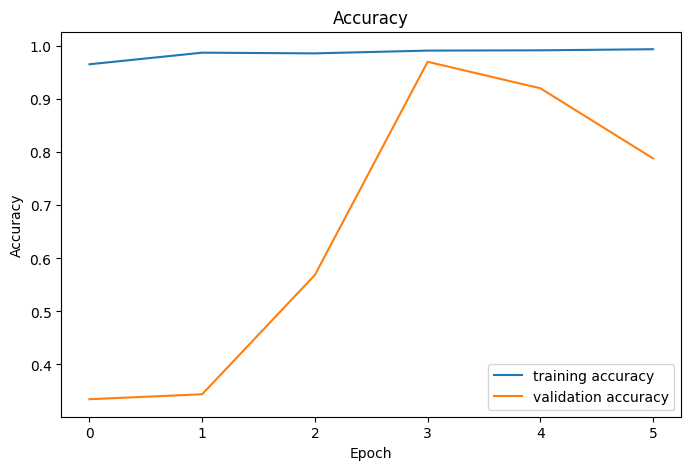

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="training accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [24]:
def predict_video(video_path):
    frames = extract_frames(video_path)

    predictions = []

    for frame in frames:
        frame = np.expand_dims(frame, axis=0)
        prediction = model.predict(frame, verbose=0)
        predictions.append(prediction[0])

    if len(predictions) == 0:
        print("No frames found in video")
        return

    average_prediction = np.mean(predictions, axis=0)
    predicted_index = np.argmax(average_prediction)

    print("Video:", video_path)
    print("Predicted action:", classes[predicted_index])
    print("Confidence:", average_prediction[predicted_index])

    return classes[predicted_index]

In [27]:
validation_videos = [
    videos_list[0][0],  # trampoline_jumping
    videos_list[1][0],  # horse_riding
    videos_list[2][0]   # tennis_swing
]

for video_path in validation_videos:
    print("=" * 50)
    predict_video(video_path)

Video: C:\Users\fh236\Downloads\action_youtube_naudio\trampoline_jumping\v_jumping_01\v_jumping_01_01.avi
Predicted action: trampoline_jumping
Confidence: 0.9996689
Video: C:\Users\fh236\Downloads\action_youtube_naudio\horse_riding\v_riding_01\v_riding_01_01.avi
Predicted action: horse_riding
Confidence: 0.9986407
Video: C:\Users\fh236\Downloads\action_youtube_naudio\tennis_swing\v_tennis_01\v_tennis_01_01.avi
Predicted action: tennis_swing
Confidence: 0.9802831


In [28]:
print("In this exercise, I used 3 classes from UCF11 dataset.")
print("The selected classes are trampoline_jumping, horse_riding, and tennis_swing.")
print("I extracted frames from videos and trained a CNN model.")
print("I validated the model using 3 videos, one video from each selected class.")

In this exercise, I used 3 classes from UCF11 dataset.
The selected classes are trampoline_jumping, horse_riding, and tennis_swing.
I extracted frames from videos and trained a CNN model.
I validated the model using 3 videos, one video from each selected class.
